# Controle des acquis de la qualite No2
### Corally Ngov(2392143) et Lina Sadat(2378349)
---


## 3.2)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

<Figure size 2160x720 with 0 Axes>

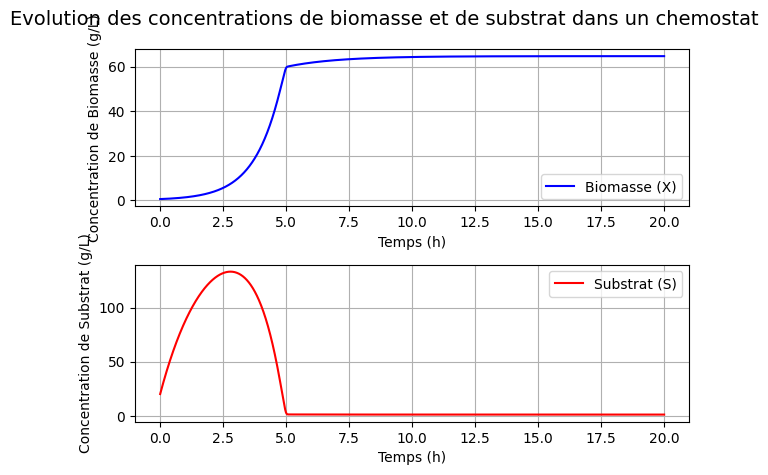

In [14]:
def bilans_matieres(t, x, p, u):
    #Variables d'état
    [X, S] = x
    #Paramètres
    [V, F0, Sin, mu_max, Ks, Yxs] = p
    #Equations
    mu = mu_max * S / (Ks + S)
    dX = -(F0/V) * X + mu * X
    dS = (F0/V) * (Sin - S) - (1/Yxs) * mu * X
    return [dX, dS]

#Conditions initiales
x0 = [0.5, 20]
p = [2.0, 1.0, 200, 1.5, 2.0, 0.325]
t_sim = [0, 20]
u0 = []

sim = solve_ivp(bilans_matieres, t_sim, x0, method = 'RK45', args = (p, u0), max_step = 0.01)


#Graphiques
plt.figure(figsize=(18, 6), dpi=120)
fig, axs = plt.subplots(nrows = 2, ncols = 1)
fig.suptitle('Evolution des concentrations de biomasse et de substrat dans un chemostat', fontsize=14)

axs[0].plot(sim.t, sim.y[0, :], 'b-', label='Biomasse (X)')
axs[0].set_xlabel('Temps (h)')
axs[0].set_ylabel('Concentration de Biomasse (g/L)')
axs[0].legend()
axs[0].grid()

axs[1].plot(sim.t, sim.y[1, :], 'r-', label='Substrat (S)')
axs[1].set_xlabel('Temps (h)')
axs[1].set_ylabel('Concentration de Substrat (g/L)')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


